In [1]:
import pandas as pd
df = pd.read_csv("cleaned_wine.csv")
df

,0.2644628099173554,0.12666667381922403,0.36000001430511475,0.30828222029048236,0.05980066742215838,0.1527777777777778,0.3778801843317972,0.8377591513897178,0.2170542635658914,0.12921347644891631,0.11594205662824104,6
0,0.206612,0.146667,0.34,0.015337,0.066445,0.045139,0.290323,0.415562,0.449612,0.151685,0.217391,6
1,0.355372,0.133333,0.40,0.096626,0.068106,0.100694,0.209677,0.481907,0.418605,0.123596,0.304348,6
2,0.280992,0.100000,0.32,0.121166,0.081395,0.159722,0.414747,0.512062,0.364341,0.101124,0.275362,6
3,0.280992,0.100000,0.32,0.121166,0.081395,0.159722,0.414747,0.512062,0.364341,0.101124,0.275362,6
4,0.355372,0.133333,0.40,0.096626,0.068106,0.100694,0.209677,0.481907,0.418605,0.123596,0.304348,6
...,...,...,...,...,...,...,...,...,...,...,...,...
6486,0.198347,0.346667,0.08,0.021472,0.134552,0.107639,0.087558,0.469842,0.565892,0.202247,0.362319,5
6487,0.173554,0.313333,0.10,0.024540,0.088040,0.131944,0.103687,0.483112,0.620155,0.303371,0.463768,6
6488,0.206612,0.286667,0.13,0.026074,0.111296,0.097222,0.078341,0.520506,0.542636,0.297753,0.434783,6
6489,0.173554,0.376667,0.12,0.021472,0.109635,0.107639,0.087558,0.504221,0.658915,0.275281,0.318841,5


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality'
]
df = pd.read_csv("cleaned_wine.csv", names=columns)

print(df.columns)

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


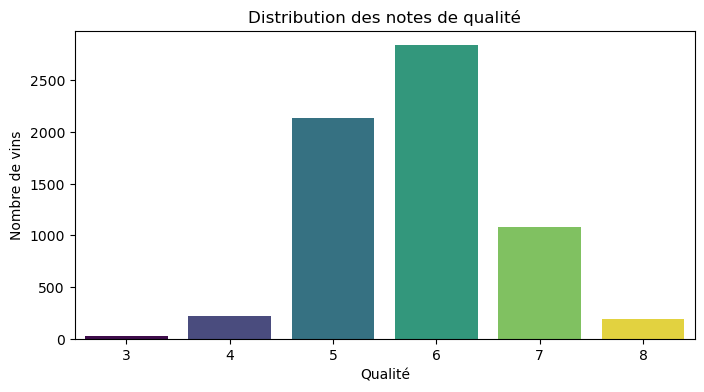

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.countplot(
    x='quality', 
    data=df, 
    hue='quality',
    palette='viridis',
    legend=False
)
plt.title('Distribution des notes de qualité')
plt.xlabel('Qualité')
plt.ylabel('Nombre de vins')
plt.show()

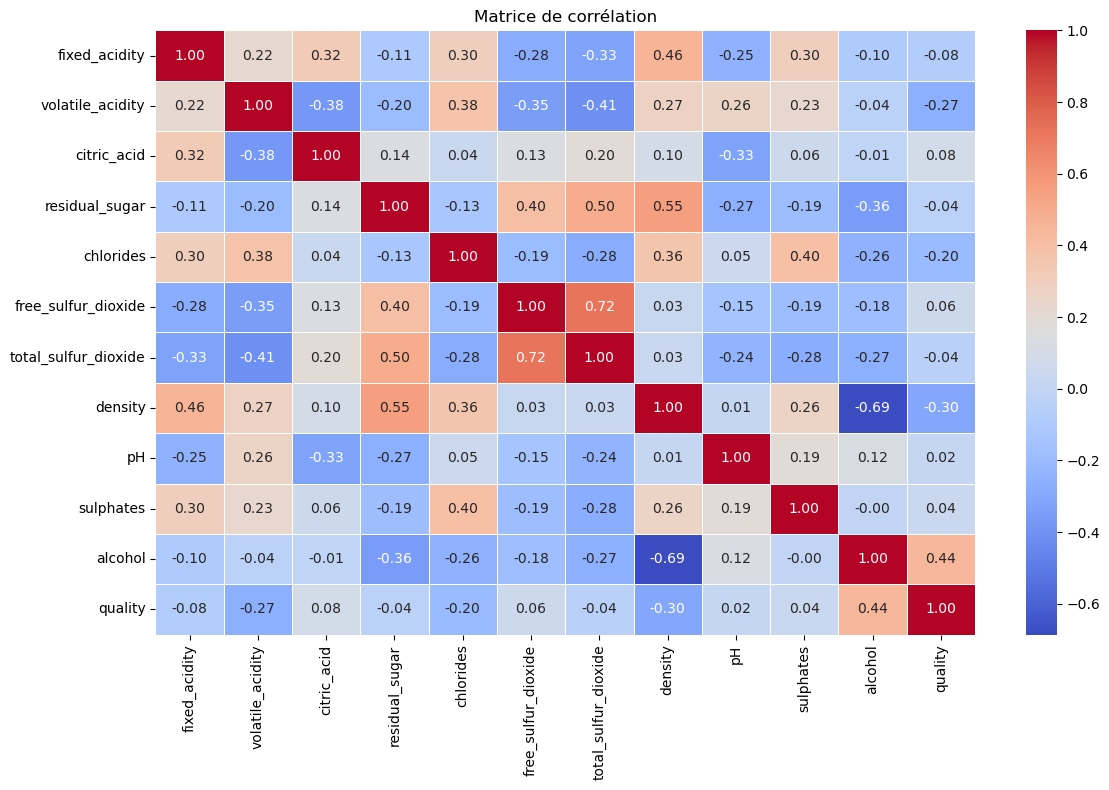

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

In [5]:
correlation_qualite = df.corr()['quality'].sort_values(ascending=False, key=abs)

print("Facteurs clés influençant la qualité du vin (par ordre de corrélation) :")
print("-" * 70)
print(correlation_qualite)

Facteurs clés influençant la qualité du vin (par ordre de corrélation) :
----------------------------------------------------------------------
quality                 1.000000
alcohol                 0.443055
density                -0.304627
volatile_acidity       -0.266371
chlorides              -0.199448
citric_acid             0.084680
fixed_acidity          -0.077598
free_sulfur_dioxide     0.055302
total_sulfur_dioxide   -0.041613
sulphates               0.039929
residual_sugar         -0.036395
pH                      0.018040
Name: quality, dtype: float64


In [6]:
import pandas as pd

df = pd.read_csv("cleaned_wine.csv")

In [7]:
import pandas as pd

df = pd.read_csv("cleaned_wine.csv", names=[
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
    'pH', 'sulphates', 'alcohol', 'quality'
])

X = df.drop("quality", axis=1)
y = df["quality"]

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(11,)),          
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 6)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,014 (3.96 KB)

 Trainable params: 1,014 (3.96 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train - 3, num_classes=6)
y_test_cat = to_categorical(y_test - 3, num_classes=6)

history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test_cat)
)

model.save("wine_model.keras")
print("模型已保存为 wine_model.keras")

Epoch 1/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4595 - loss: 1.3073 - val_accuracy: 0.5273 - val_loss: 1.1532
Epoch 2/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5423 - loss: 1.1105 - val_accuracy: 0.5389 - val_loss: 1.1140
Epoch 3/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5540 - loss: 1.0760 - val_accuracy: 0.5350 - val_loss: 1.0916
Epoch 4/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5617 - loss: 1.0577 - val_accuracy: 0.5473 - val_loss: 1.0786
Epoch 5/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5623 - loss: 1.0446 - val_accuracy: 0.5420 - val_loss: 1.0739
Epoch 6/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5625 - loss: 1.0335 - val_accuracy: 0.5396 - val_loss: 1.0775
Epoch 7/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5667 - loss: 1.0239 - val_accuracy: 0.5450 - val_loss: 1.0658
Epoch 8/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5646 - loss: 1.0164 - val_accuracy: 0.

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5597 - loss: 1.0391
Précision finale sur jeu de test : 0.5596612691879272


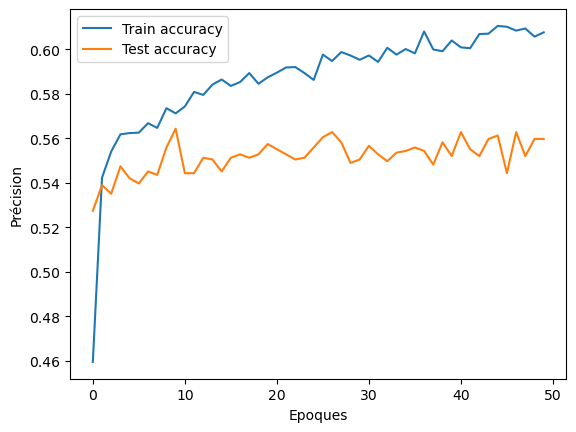

In [12]:
import matplotlib.pyplot as plt

test_loss, test_acc = model.evaluate(X_test, to_categorical(y_test - 3, 6))
print("Précision finale sur jeu de test :", test_acc)

plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Test accuracy')
plt.xlabel('Epoques')
plt.ylabel('Précision')
plt.legend()
plt.show()

In [13]:
import pandas as pd
df = pd.read_csv("cleaned_wine.csv")
print(df.columns)

Index(['0.2644628099173554', '0.12666667381922403', '0.36000001430511475',
       '0.30828222029048236', '0.05980066742215838', '0.1527777777777778',
       '0.3778801843317972', '0.8377591513897178', '0.2170542635658914',
       '0.12921347644891631', '0.11594205662824104', '6'],
      dtype='object')


In [14]:
import pandas as pd

df = pd.read_csv("cleaned_wine.csv", header=None)

df.columns = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "quality"
]

df.to_csv("cleaned_wine_fixed.csv", index=False)
print("数据修复完成！新文件已保存为 cleaned_wine_fixed.csv")
print("修复后的列名：")
print(df.columns)

数据修复完成！新文件已保存为 cleaned_wine_fixed.csv
修复后的列名：
Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [15]:
# Étape 5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from tensorflow.keras.models import load_model

In [16]:
df = pd.read_csv("cleaned_wine_fixed.csv")

X = df.drop("quality", axis=1).values
y_true_score = df["quality"].values

y_class = y_true_score - 3

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
model = load_model("wine_model.keras")
print("模型加载成功")

模型加载成功


In [19]:
y_pred_proba = model.predict(X_scaled, verbose=0)
y_pred_class = np.argmax(y_pred_proba, axis=1)
y_pred_score = y_pred_class + 3

acc = accuracy_score(y_class, y_pred_class)
precision = precision_score(y_class, y_pred_class, average="weighted", zero_division=0)
recall = recall_score(y_class, y_pred_class, average="weighted", zero_division=0)
f1 = f1_score(y_class, y_pred_class, average="weighted", zero_division=0)
mse = mean_squared_error(y_true_score, y_pred_score)
mae = mean_absolute_error(y_true_score, y_pred_score)
rmse = np.sqrt(mse)

print(f"Accuracy        : {acc:.4f}")
print(f"Précision       : {precision:.4f}")
print(f"Rappel          : {recall:.4f}")
print(f"F1-score        : {f1:.4f}")
print(f"MSE             : {mse:.4f}")
print(f"MAE             : {mae:.4f}")
print(f"RMSE            : {rmse:.4f}")

Accuracy        : 0.6038
Précision       : 0.5811
Rappel          : 0.6038
F1-score        : 0.5826
MSE             : 0.5142
MAE             : 0.4341
RMSE            : 0.7171


In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled)):
    X_test_cv = X_scaled[test_idx]
    y_test_cv = y_class[test_idx]
    
    y_pred_cv = np.argmax(model.predict(X_test_cv, verbose=0), axis=1)
    cv_acc.append(accuracy_score(y_test_cv, y_pred_cv))

print(f"Accuracy par pli : {[round(x,4) for x in cv_acc]}")
print(f"Accuracy moyenne : {np.mean(cv_acc):.4f}")
print(f"Écart-type       : {np.std(cv_acc):.4f}")

Accuracy par pli : [0.5597, 0.6074, 0.5971, 0.6364, 0.6186]
Accuracy moyenne : 0.6038
Écart-type       : 0.0256


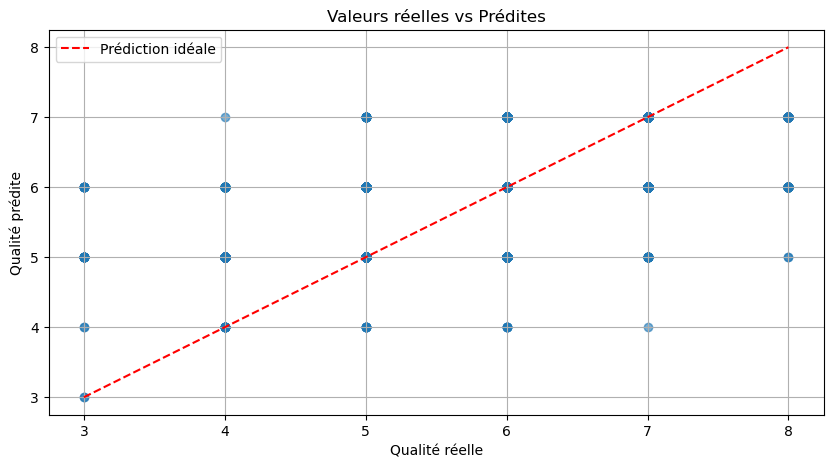

In [21]:
plt.figure(figsize=(10,5))
plt.scatter(y_true_score, y_pred_score, alpha=0.6, color='#1f77b4')
plt.plot([3,8], [3,8], 'r--', label='Prédiction idéale')
plt.xlabel("Qualité réelle")
plt.ylabel("Qualité prédite")
plt.title("Valeurs réelles vs Prédites")
plt.legend()
plt.grid(True)
plt.show()

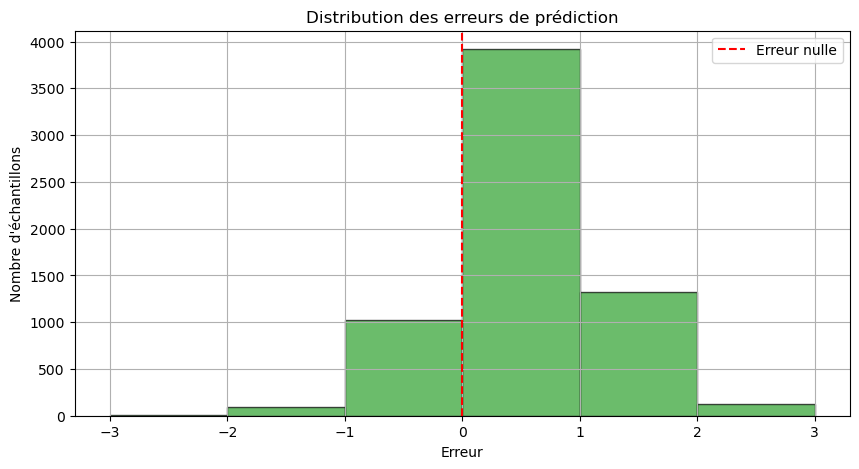

In [22]:
erreurs = y_true_score - y_pred_score

plt.figure(figsize=(10,5))
plt.hist(erreurs, bins=range(-3, 4), color='#2ca02c', alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Erreur nulle')
plt.xlabel("Erreur")
plt.ylabel("Nombre d'échantillons")
plt.title("Distribution des erreurs de prédiction")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Étape 6.1 : Installer et importer les bibliothèques
%pip install fastapi uvicorn nest_asyncio
import nest_asyncio
nest_asyncio.apply()  # 解决Jupyter异步报错
from fastapi import FastAPI
import uvicorn
from tensorflow.keras.models import load_model
import numpy as np

Note: you may need to restart the kernel to use updated packages.


In [25]:
# Étape 6.2 : Charger le modèle entraîné

model = load_model("wine_model.keras")
print("Modèle chargé avec succès !")

Modèle chargé avec succès !


In [49]:
# Étape 6.3 : Créer l'application API

app = FastAPI(
    title="API Prédiction Qualité Vin",
    description="Prédire la qualité du vin à partir de ses caractéristiques"
)
print("API créée !")

API créée !
